In [6]:
import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [7]:
n = 3
d_hat = int(np.ceil(np.log2(2)))
j0 = QuantumRegister(n, "j^{(0)}")
j1 = QuantumRegister(n, "j^{(1)}")
l = QuantumRegister(2, "l")
k = QuantumRegister(d_hat, "k")

simulator = AerSimulator(method="unitary")

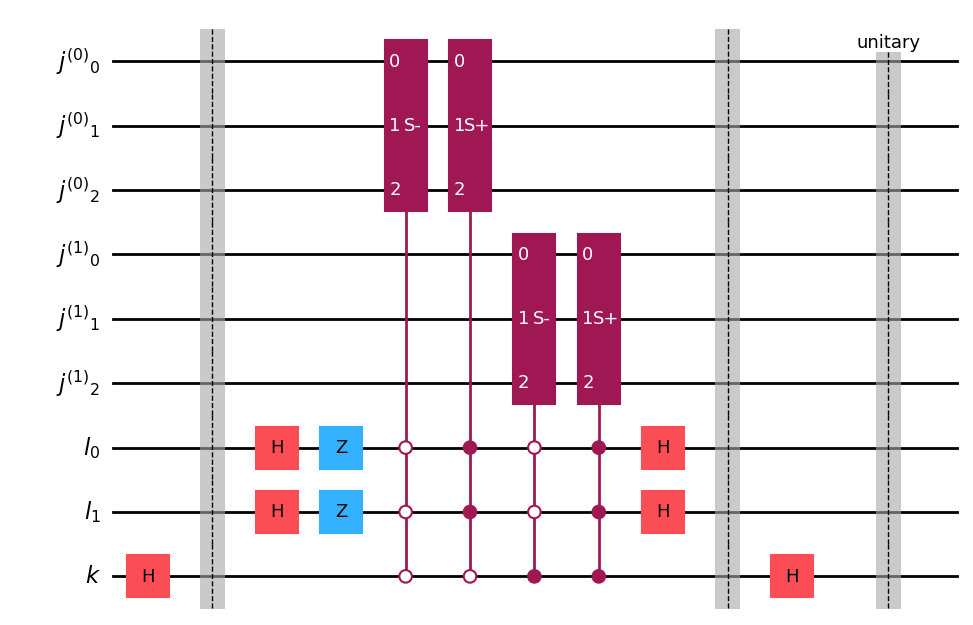

In [8]:
csdown0 = ShiftDown(n).control(3, ctrl_state="000")
csup0 = ShiftUp(n).control(3, ctrl_state="011")
csdown1 = ShiftDown(n).control(3, ctrl_state="100")
csup1 = ShiftUp(n).control(3, ctrl_state="111")
qc = QuantumCircuit(j0, j1, l, k)

# Block encoding
qc.h(k)
qc.barrier()
qc.h(l)
qc.z(l)
qc.append(csdown0, l[:] + k[:] + j0[:])
qc.append(csup0, l[:] + k[:] + j0[:])
qc.append(csdown1, l[:] + k[:] + j1[:])
qc.append(csup1, l[:] + k[:] + j1[:])
qc.h(l)
qc.barrier()
qc.h(k)
qc.save_unitary()

qc.draw(output="mpl")

In [9]:
qc = transpile(qc, simulator)

result = simulator.run(qc).result()
unitary = result.get_unitary(qc).data

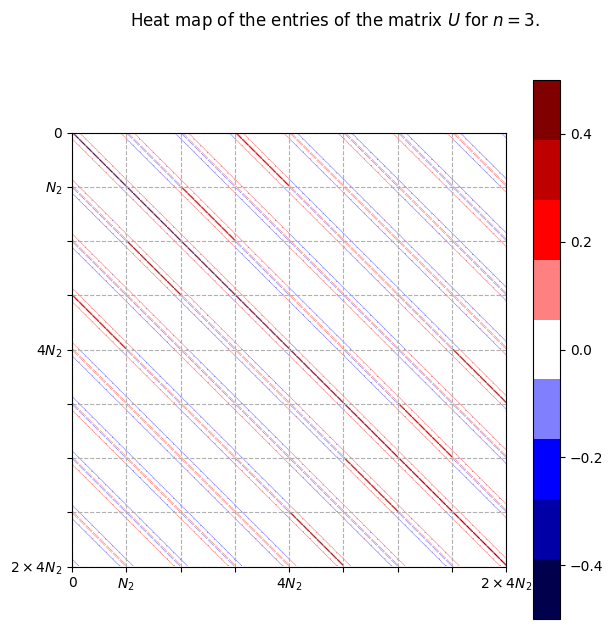

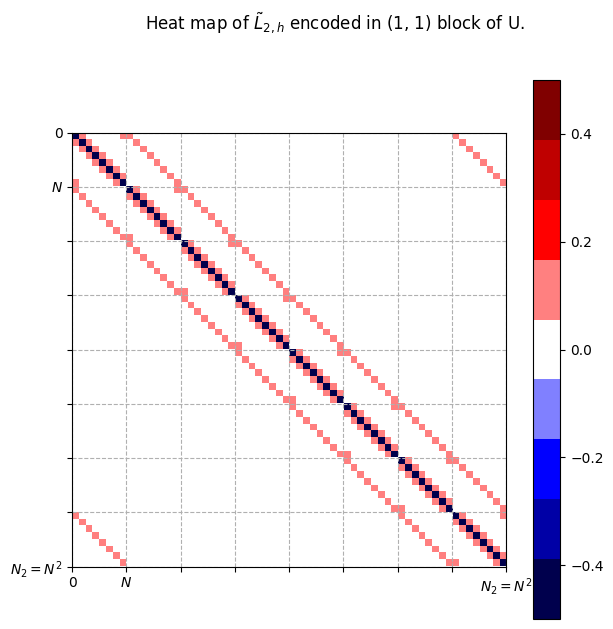

In [10]:
cmap = plt.get_cmap("seismic", 9)
ticks = np.array(list(range(0, 2 ** 9 + 1, 64)))

plt.figure(figsize=(7, 7))
plt.suptitle("Heat map of the entries of the matrix $U$ for $n = 3$.")
plt.imshow(unitary.real, cmap=cmap, vmin=-0.5, vmax=0.5)
plt.colorbar()

plt.gca().set_xticks(ticks - 0.5)
plt.gca().set_xticklabels([0] + ["$N_2$"] + 2 * [None] + ["$4N_2$"] + 3 * [None] + ["$2 \\times 4N_2$"])
plt.gca().set_yticks(ticks - 0.5)
plt.gca().set_yticklabels([0] + ["$N_2$"] + 2 * [None] + ["$4N_2$"] + 3 * [None] + ["$2 \\times 4N_2$"])
plt.grid(linestyle="--")
plt.show()

ticks = np.array(list(range(0, 2 ** 6 + 1, 8)))
plt.figure(figsize=(7, 7))
plt.suptitle("Heat map of $\\tilde{L}_{{2, h}}$ encoded in (1, 1) block of U.")
plt.imshow(unitary[:64, :64].real, cmap=cmap, vmin=-0.5, vmax=0.5)
plt.colorbar()

plt.gca().set_xticks(ticks - 0.5)
plt.gca().set_xticklabels([0] + ["$N$"] + 6 * [None] + ["$N_2 = N^2$"])
plt.gca().set_yticks(ticks - 0.5)
plt.gca().set_yticklabels([0] + ["$N$"] + 6 * [None] + ["$N_2 = N^2$"])
plt.grid(linestyle="--")
plt.show()